In [105]:
# importing libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [106]:
# loading the dataset
df = pd.read_csv("International_Education.csv", encoding='latin-1')
df.head()

,Countries and areas,Latitude,Longitude,OOSR_Pre0Primary_Age_Male,OOSR_Pre0Primary_Age_Female,OOSR_Primary_Age_Male,OOSR_Primary_Age_Female,OOSR_Lower_Secondary_Age_Male,OOSR_Lower_Secondary_Age_Female,OOSR_Upper_Secondary_Age_Male,...,Primary_End_Proficiency_Reading,Primary_End_Proficiency_Math,Lower_Secondary_End_Proficiency_Reading,Lower_Secondary_End_Proficiency_Math,Youth_15_24_Literacy_Rate_Male,Youth_15_24_Literacy_Rate_Female,Birth_Rate,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment,Unemployment_Rate
0,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,44,...,13,11,0,0,74,56,32.49,104.0,9.7,11.12
1,Albania,41.153332,20.168331,4,2,6,3,6,1,21,...,0,0,48,58,99,100,11.78,107.0,55.0,12.33
2,Algeria,28.033886,1.659626,0,0,0,0,0,0,0,...,0,0,21,19,98,97,24.28,109.9,51.4,11.70
3,Andorra,42.506285,1.521801,0,0,0,0,0,0,0,...,0,0,0,0,0,0,7.20,106.4,0.0,0.00
4,Angola,11.202692,17.873887,31,39,0,0,0,0,0,...,0,0,0,0,0,0,40.73,113.5,9.3,6.89


In [107]:
df.shape

(202, 29)

In [108]:
df.columns

Index(['Countries and areas', 'Latitude ', 'Longitude',
       'OOSR_Pre0Primary_Age_Male', 'OOSR_Pre0Primary_Age_Female',
       'OOSR_Primary_Age_Male', 'OOSR_Primary_Age_Female',
       'OOSR_Lower_Secondary_Age_Male', 'OOSR_Lower_Secondary_Age_Female',
       'OOSR_Upper_Secondary_Age_Male', 'OOSR_Upper_Secondary_Age_Female',
       'Completion_Rate_Primary_Male', 'Completion_Rate_Primary_Female',
       'Completion_Rate_Lower_Secondary_Male',
       'Completion_Rate_Lower_Secondary_Female',
       'Completion_Rate_Upper_Secondary_Male',
       'Completion_Rate_Upper_Secondary_Female',
       'Grade_2_3_Proficiency_Reading', 'Grade_2_3_Proficiency_Math',
       'Primary_End_Proficiency_Reading', 'Primary_End_Proficiency_Math',
       'Lower_Secondary_End_Proficiency_Reading',
       'Lower_Secondary_End_Proficiency_Math',
       'Youth_15_24_Literacy_Rate_Male', 'Youth_15_24_Literacy_Rate_Female',
       'Birth_Rate', 'Gross_Primary_Education_Enrollment',
       'Gross_Tertiary_Edu

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Countries and areas                      202 non-null    object 
 1   Latitude                                 202 non-null    float64
 2   Longitude                                202 non-null    float64
 3   OOSR_Pre0Primary_Age_Male                202 non-null    int64  
 4   OOSR_Pre0Primary_Age_Female              202 non-null    int64  
 5   OOSR_Primary_Age_Male                    202 non-null    int64  
 6   OOSR_Primary_Age_Female                  202 non-null    int64  
 7   OOSR_Lower_Secondary_Age_Male            202 non-null    int64  
 8   OOSR_Lower_Secondary_Age_Female          202 non-null    int64  
 9   OOSR_Upper_Secondary_Age_Male            202 non-null    int64  
 10  OOSR_Upper_Secondary_Age_Female          202 non-n

In [110]:
# Filtering african countries
african_countries = [
    "Algeria", "Angola", "Benin", "Botswana", "Burkina Faso",
    "Burundi", "Cameroon", "Cape Verde", "Central African Republic",
    "Chad", "Comoros", "Republic of the Congo", "Democratic Republic of the Congo",
    "Djibouti", "Egypt", "Equatorial Guinea", "Eritrea",
    "Eswatini", "Ethiopia", "Gabon", "Gambia", "Ghana",
    "Guinea", "Guinea0Bissau", "Ivory Coast", "Kenya",
    "Lesotho", "Liberia", "Libya", "Madagascar", "Malawi",
    "Mali", "Mauritania", "Mauritius", "Morocco", "Mozambique",
    "Namibia", "Niger", "Nigeria", "Rwanda", "Sao Tome and Principe",
    "Senegal", "Seychelles", "Sierra Leone", "Somalia",
    "South Africa", "South Sudan", "Sudan", "Tanzania",
    "Togo", "Tunisia", "Uganda", "Zambia", "Zimbabwe"
]

df = df[df["Countries and areas"].isin(african_countries)]

In [111]:
african_in_dataset = set(df_africa["Countries and areas"].unique())
expected = set(african_countries)

missing = expected - african_in_dataset
extra = african_in_dataset - expected

print("Missing from dataset:", sorted(missing))
print("Extra in dataset:", sorted(extra))

Missing from dataset: []
Extra in dataset: []


In [112]:
len(african_countries)

54

In [113]:
print(df.shape)

(54, 29)


In [114]:
df.isnull().sum().sort_values(ascending=False)

,0
Countries and areas,0
Latitude,0
Longitude,0
OOSR_Pre0Primary_Age_Male,0
OOSR_Pre0Primary_Age_Female,0
OOSR_Primary_Age_Male,0
OOSR_Primary_Age_Female,0
OOSR_Lower_Secondary_Age_Male,0
OOSR_Lower_Secondary_Age_Female,0
OOSR_Upper_Secondary_Age_Male,0


In [115]:
df.duplicated().sum()

np.int64(0)

In [116]:
df.drop_duplicates(inplace=True)

In [117]:
df.dtypes

,0
Countries and areas,object
Latitude,float64
Longitude,float64
OOSR_Pre0Primary_Age_Male,int64
OOSR_Pre0Primary_Age_Female,int64
OOSR_Primary_Age_Male,int64
OOSR_Primary_Age_Female,int64
OOSR_Lower_Secondary_Age_Male,int64
OOSR_Lower_Secondary_Age_Female,int64
OOSR_Upper_Secondary_Age_Male,int64


In [118]:
df_africa = df.copy()
print('df_africa created successfully!')

df_africa created successfully!


In [119]:
df_africa = df.copy()

In [120]:
df_africa.head()

,Countries and areas,Latitude,Longitude,OOSR_Pre0Primary_Age_Male,OOSR_Pre0Primary_Age_Female,OOSR_Primary_Age_Male,OOSR_Primary_Age_Female,OOSR_Lower_Secondary_Age_Male,OOSR_Lower_Secondary_Age_Female,OOSR_Upper_Secondary_Age_Male,...,Primary_End_Proficiency_Reading,Primary_End_Proficiency_Math,Lower_Secondary_End_Proficiency_Reading,Lower_Secondary_End_Proficiency_Math,Youth_15_24_Literacy_Rate_Male,Youth_15_24_Literacy_Rate_Female,Birth_Rate,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment,Unemployment_Rate
2,Algeria,28.033886,1.659626,0,0,0,0,0,0,0,...,0,0,21,19,98,97,24.28,109.9,51.4,11.70
4,Angola,11.202692,17.873887,31,39,0,0,0,0,0,...,0,0,0,0,0,0,40.73,113.5,9.3,6.89
19,Benin,9.307690,2.315834,15,16,3,10,27,43,46,...,23,11,0,0,70,52,36.22,122.0,12.3,2.23
23,Botswana,22.328474,24.684866,79,78,12,10,0,0,0,...,0,16,0,0,0,0,24.82,103.2,24.9,18.19
28,Burkina Faso,12.238333,1.561593,81,81,21,22,48,44,67,...,21,22,0,0,62,55,37.93,96.1,6.5,6.26


In [121]:
df_africa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 2 to 201
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Countries and areas                      54 non-null     object 
 1   Latitude                                 54 non-null     float64
 2   Longitude                                54 non-null     float64
 3   OOSR_Pre0Primary_Age_Male                54 non-null     int64  
 4   OOSR_Pre0Primary_Age_Female              54 non-null     int64  
 5   OOSR_Primary_Age_Male                    54 non-null     int64  
 6   OOSR_Primary_Age_Female                  54 non-null     int64  
 7   OOSR_Lower_Secondary_Age_Male            54 non-null     int64  
 8   OOSR_Lower_Secondary_Age_Female          54 non-null     int64  
 9   OOSR_Upper_Secondary_Age_Male            54 non-null     int64  
 10  OOSR_Upper_Secondary_Age_Female          54 non-null    

In [122]:
df["Countries and areas"].sort_values().unique()

array(['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso',
       'Burundi', 'Cameroon', 'Cape Verde', 'Central African Republic',
       'Chad', 'Comoros', 'Democratic Republic of the Congo', 'Djibouti',
       'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia',
       'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea0Bissau',
       'Ivory Coast', 'Kenya', 'Lesotho', 'Liberia', 'Libya',
       'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius',
       'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria',
       'Republic of the Congo', 'Rwanda', 'Sao Tome and Principe',
       'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa',
       'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda',
       'Zambia', 'Zimbabwe'], dtype=object)

In [123]:
df.shape

(54, 29)

In [124]:
df.drop(columns=[
    "Countries and areas",
    "Latitude ",
    "Longitude"
], inplace=True)

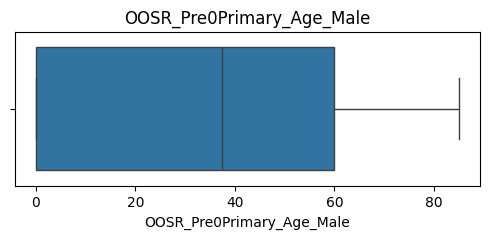

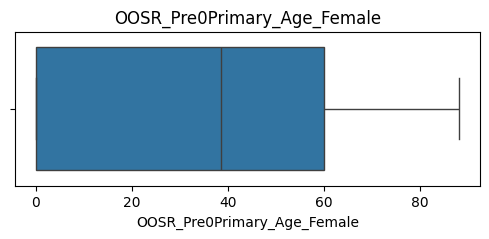

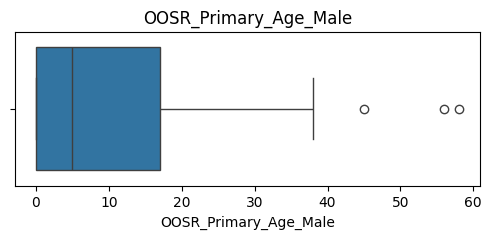

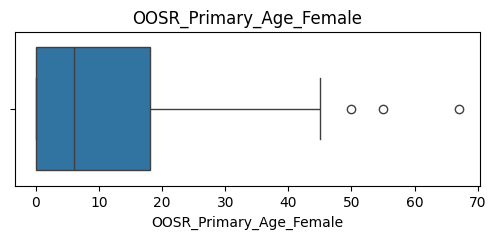

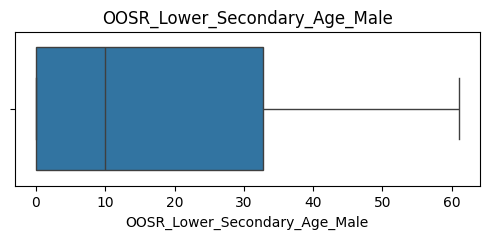

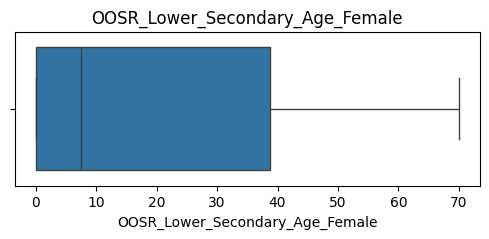

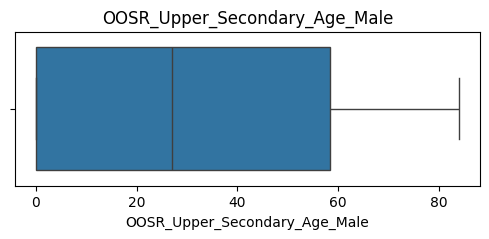

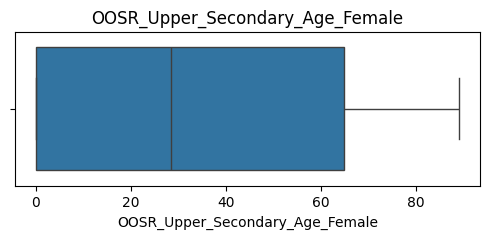

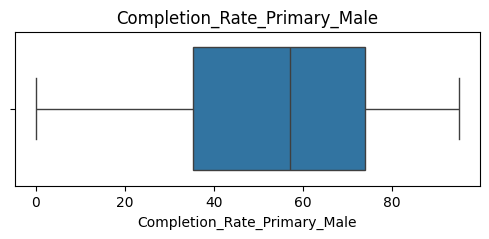

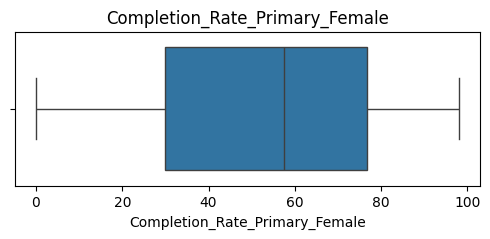

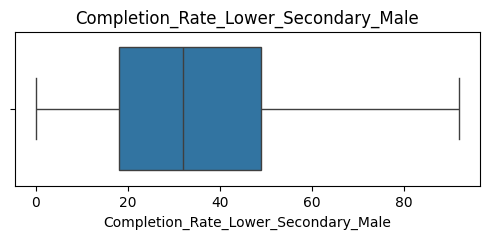

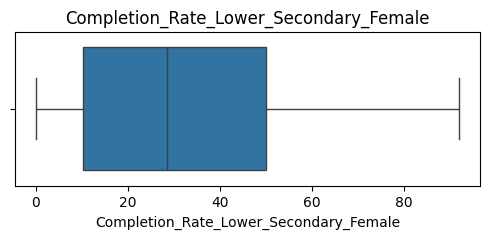

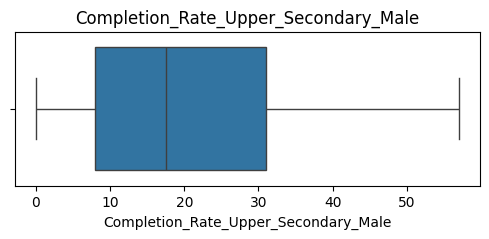

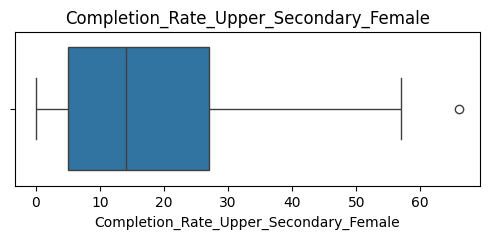

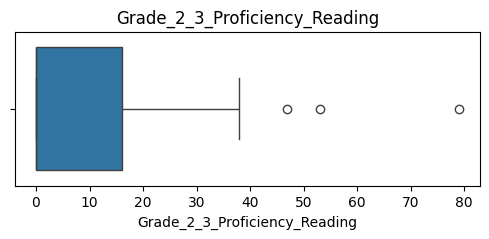

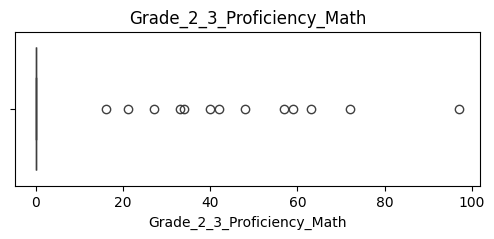

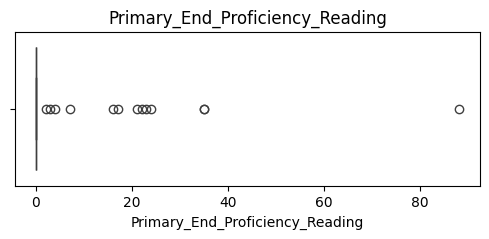

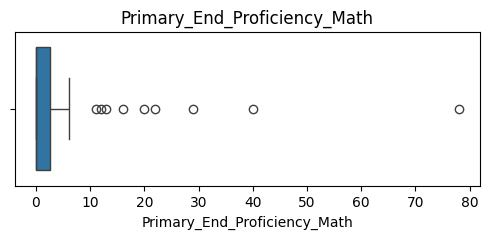

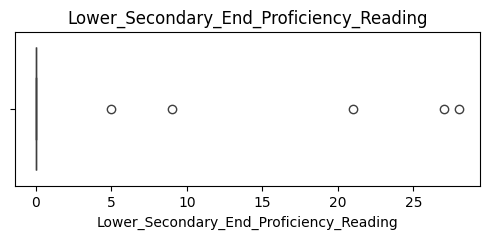

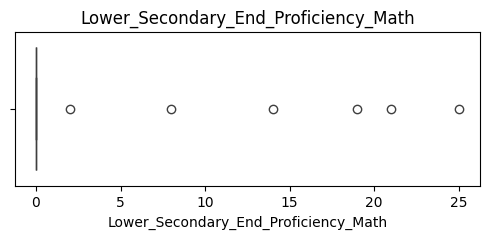

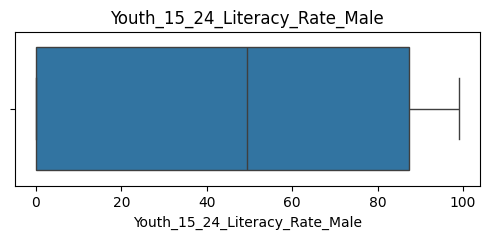

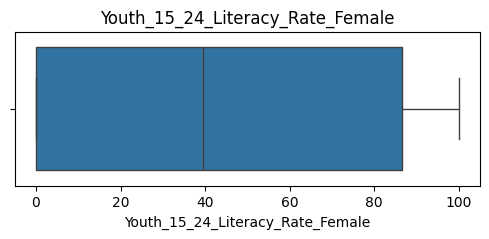

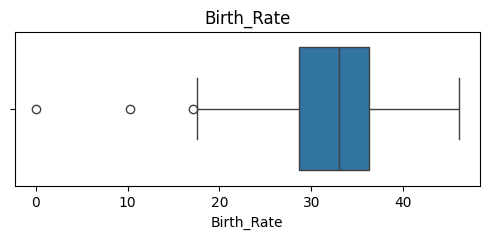

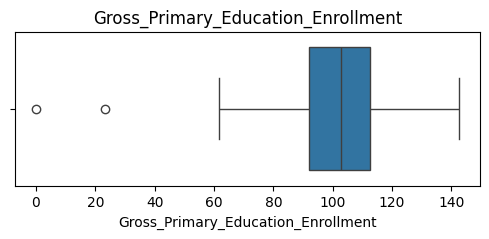

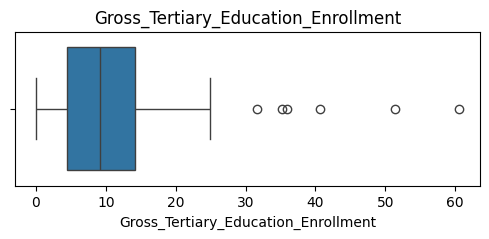

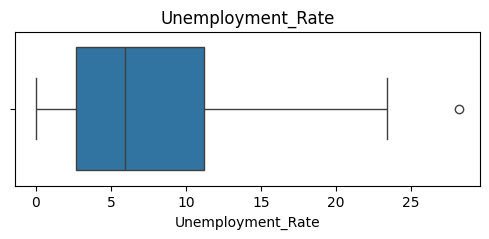

In [125]:
numerical_columns = df.select_dtypes(include=["float64","int64"]).columns

for column in numerical_columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[column])
    plt.title(column)
    plt.show()

In [126]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
OOSR_Pre0Primary_Age_Male,54.0,35.851852,30.970106,0.0,0.0000,37.500,60.0000,85.00
OOSR_Pre0Primary_Age_Female,54.0,35.851852,31.016981,0.0,0.0000,38.500,60.0000,88.00
OOSR_Primary_Age_Male,54.0,11.425926,14.782195,0.0,0.0000,5.000,17.0000,58.00
OOSR_Primary_Age_Female,54.0,12.574074,16.319455,0.0,0.0000,6.000,18.0000,67.00
OOSR_Lower_Secondary_Age_Male,54.0,17.092593,19.250355,0.0,0.0000,10.000,32.7500,61.00
OOSR_Lower_Secondary_Age_Female,54.0,18.740741,22.376862,0.0,0.0000,7.500,38.7500,70.00
OOSR_Upper_Secondary_Age_Male,54.0,31.925926,28.535877,0.0,0.0000,27.000,58.5000,84.00
OOSR_Upper_Secondary_Age_Female,54.0,34.259259,31.563763,0.0,0.0000,28.500,64.7500,89.00
Completion_Rate_Primary_Male,54.0,51.777778,29.089106,0.0,35.2500,57.000,74.0000,95.00
Completion_Rate_Primary_Female,54.0,52.185185,31.443915,0.0,30.0000,57.500,76.7500,98.00


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 2 to 201
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   OOSR_Pre0Primary_Age_Male                54 non-null     int64  
 1   OOSR_Pre0Primary_Age_Female              54 non-null     int64  
 2   OOSR_Primary_Age_Male                    54 non-null     int64  
 3   OOSR_Primary_Age_Female                  54 non-null     int64  
 4   OOSR_Lower_Secondary_Age_Male            54 non-null     int64  
 5   OOSR_Lower_Secondary_Age_Female          54 non-null     int64  
 6   OOSR_Upper_Secondary_Age_Male            54 non-null     int64  
 7   OOSR_Upper_Secondary_Age_Female          54 non-null     int64  
 8   Completion_Rate_Primary_Male             54 non-null     int64  
 9   Completion_Rate_Primary_Female           54 non-null     int64  
 10  Completion_Rate_Lower_Secondary_Male     54 non-null    

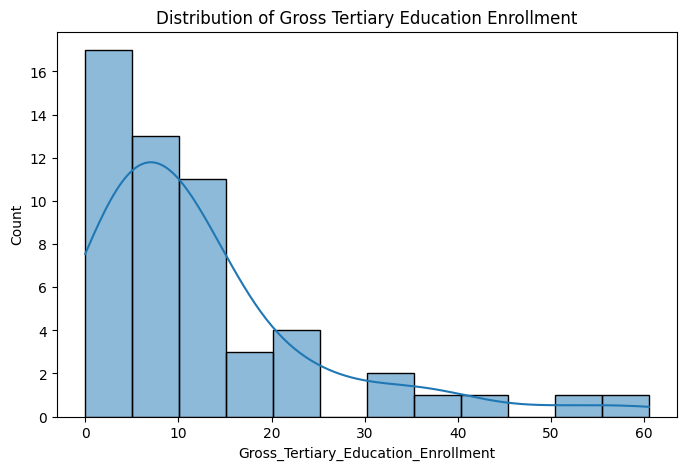

In [128]:
plt.figure(figsize=(8,5))
sns.histplot(df["Gross_Tertiary_Education_Enrollment"], kde=True)
plt.title("Distribution of Gross Tertiary Education Enrollment"),
plt.show()

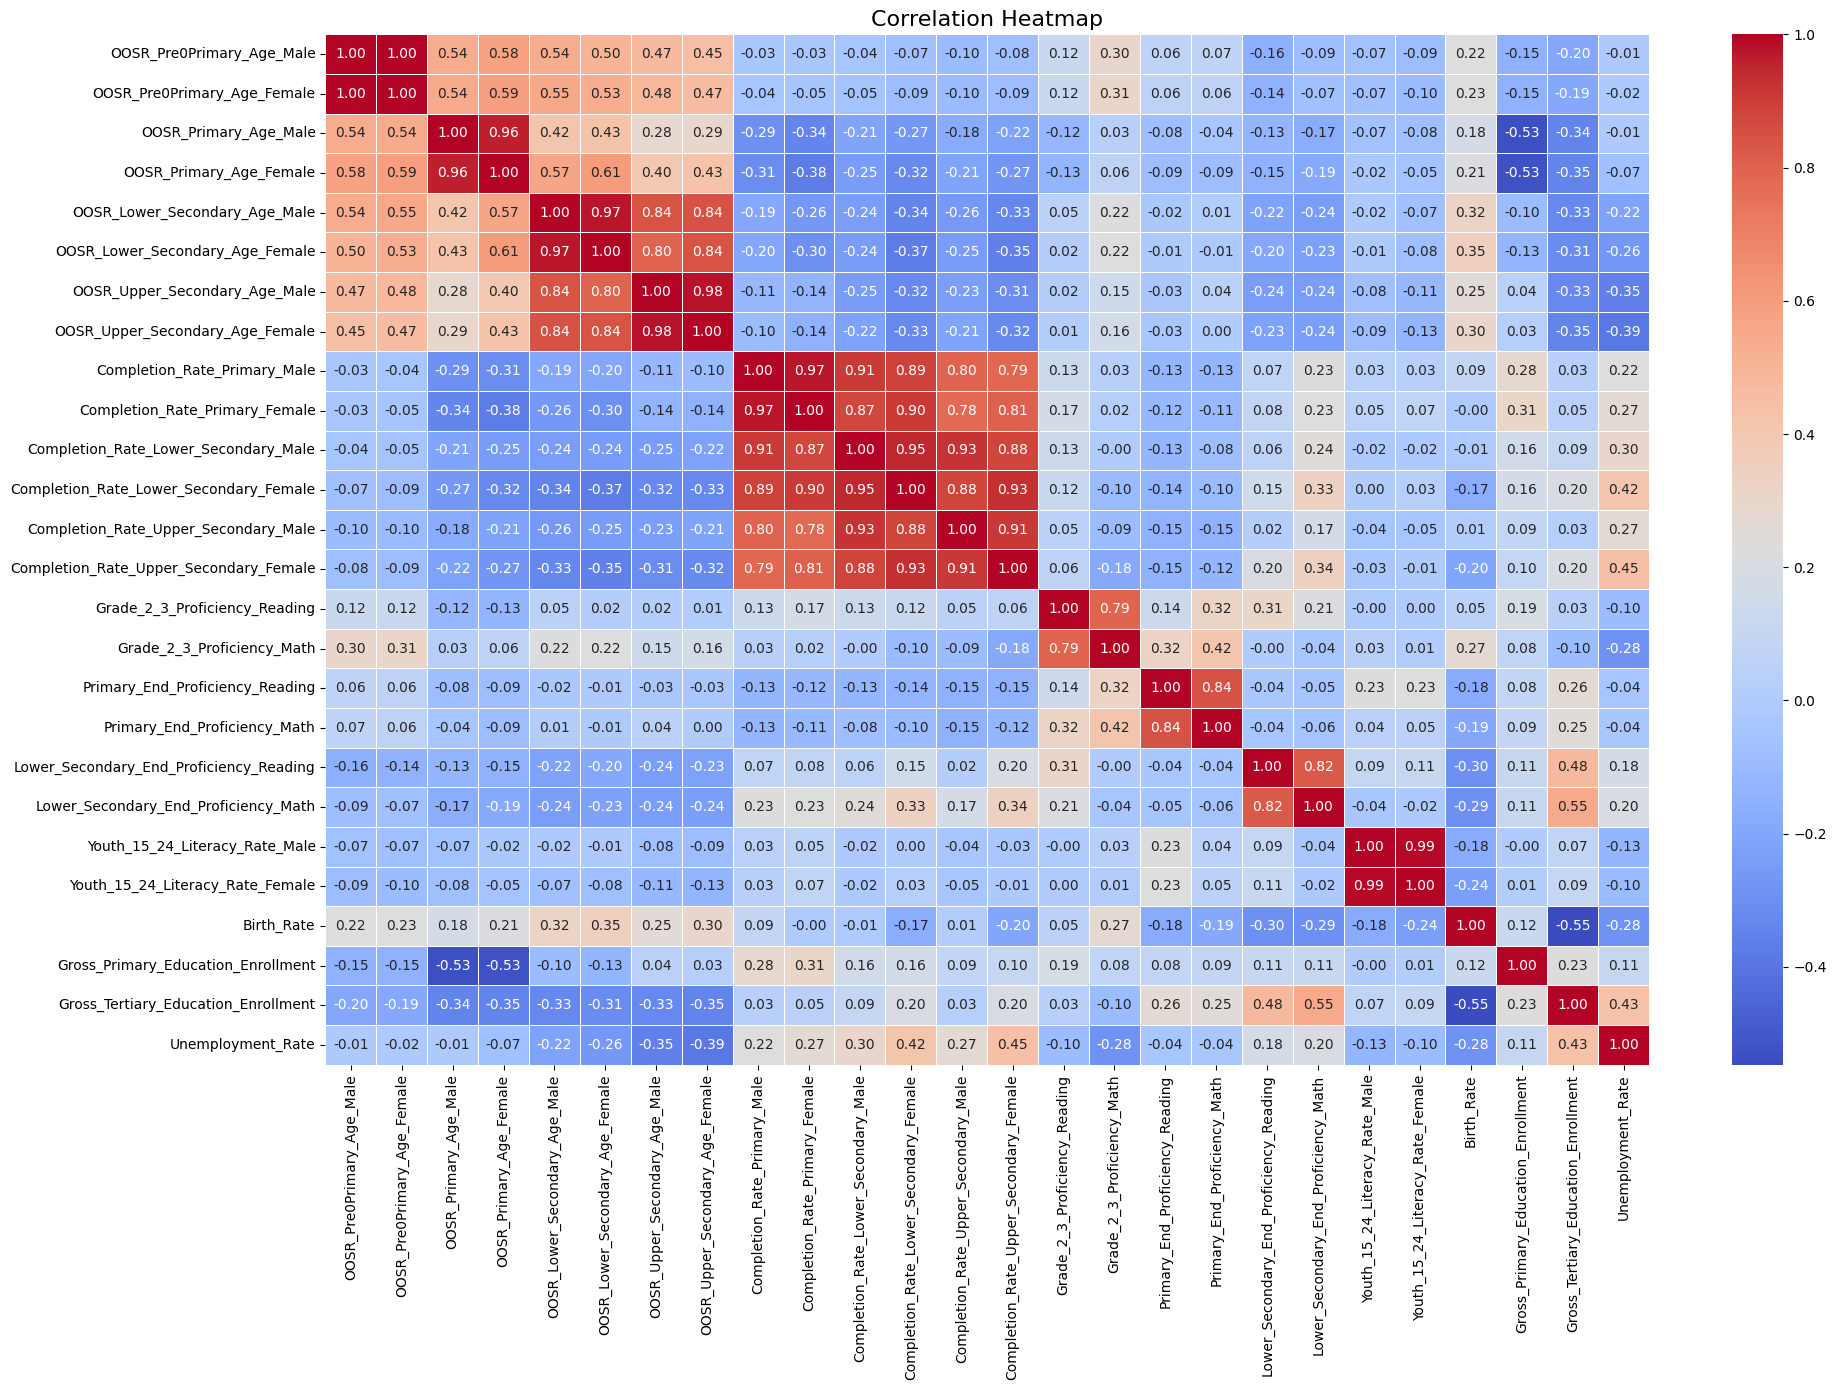

In [129]:
plt.figure(figsize=(20, 14))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

<Axes: xlabel='Unemployment_Rate', ylabel='Gross_Tertiary_Education_Enrollment'>

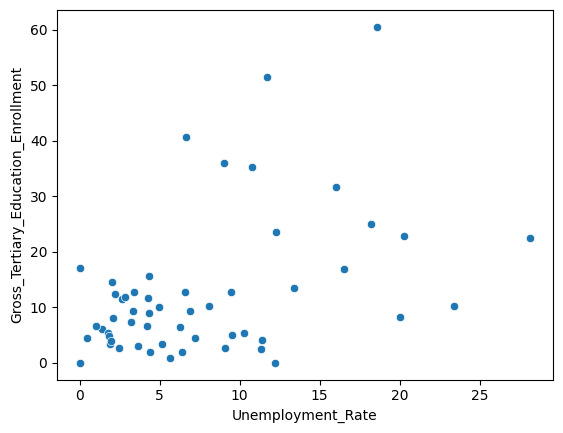

In [130]:
sns.scatterplot(
    x="Unemployment_Rate",
    y="Gross_Tertiary_Education_Enrollment",
    data=df
)

<Axes: xlabel='Birth_Rate', ylabel='Gross_Tertiary_Education_Enrollment'>

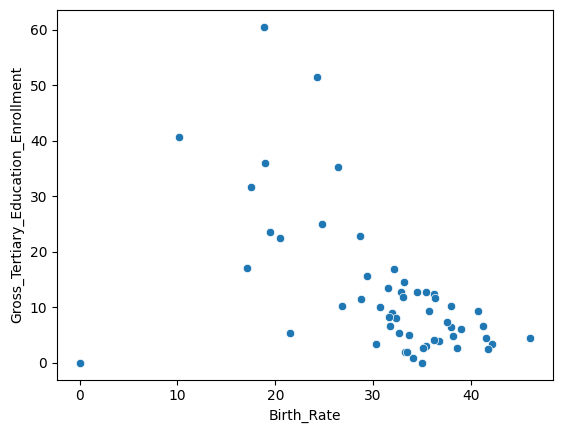

In [131]:
sns.scatterplot(
    x="Birth_Rate",
    y="Gross_Tertiary_Education_Enrollment",
    data=df
)

<Axes: xlabel='Youth_15_24_Literacy_Rate_Male', ylabel='Gross_Tertiary_Education_Enrollment'>

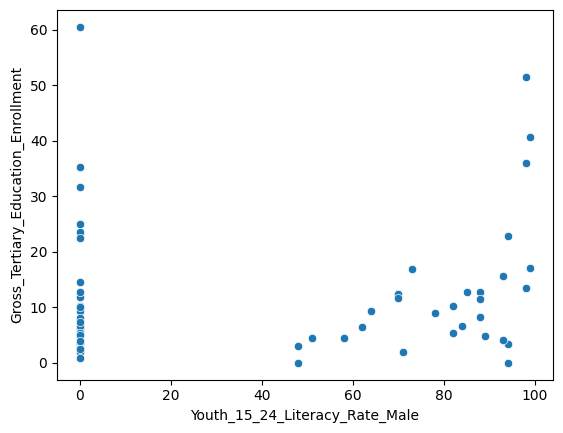

In [132]:
sns.scatterplot(
    x="Youth_15_24_Literacy_Rate_Male",
    y="Gross_Tertiary_Education_Enrollment",
    data=df
)

<Axes: xlabel='Youth_15_24_Literacy_Rate_Female', ylabel='Gross_Tertiary_Education_Enrollment'>

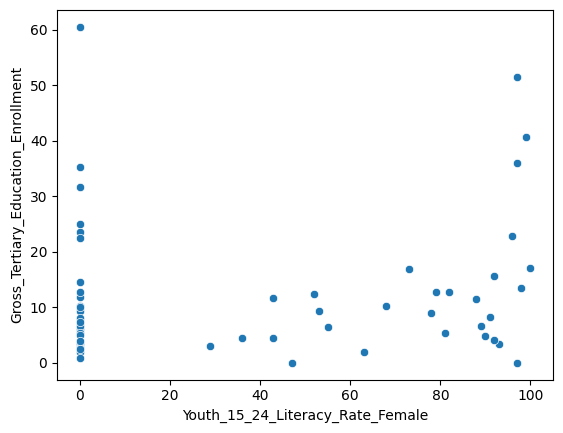

In [133]:
sns.scatterplot(
    x="Youth_15_24_Literacy_Rate_Female",
    y="Gross_Tertiary_Education_Enrollment",
    data=df
)

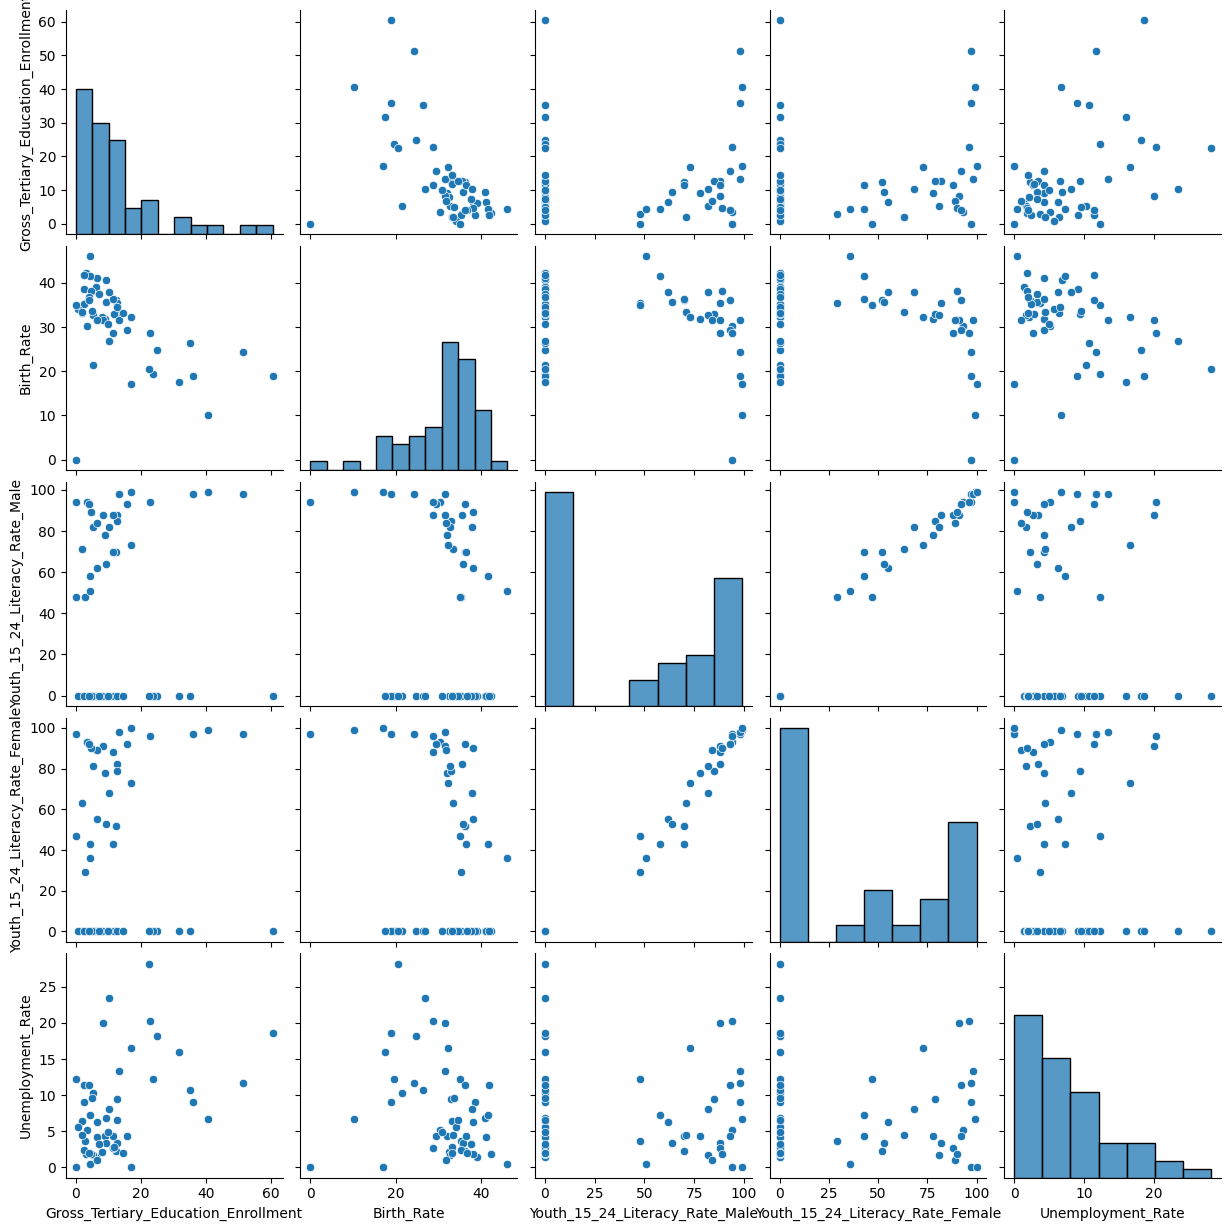

In [134]:
sns.pairplot(
    df[[
        "Gross_Tertiary_Education_Enrollment",
        "Birth_Rate",
        "Youth_15_24_Literacy_Rate_Male",
        "Youth_15_24_Literacy_Rate_Female",
        "Unemployment_Rate"
    ]]
)

In [135]:
df.isnull().sum().sort_values(ascending=False)

,0
OOSR_Pre0Primary_Age_Male,0
OOSR_Pre0Primary_Age_Female,0
OOSR_Primary_Age_Male,0
OOSR_Primary_Age_Female,0
OOSR_Lower_Secondary_Age_Male,0
OOSR_Lower_Secondary_Age_Female,0
OOSR_Upper_Secondary_Age_Male,0
OOSR_Upper_Secondary_Age_Female,0
Completion_Rate_Primary_Male,0
Completion_Rate_Primary_Female,0


In [136]:
correlation_with_target = (
    df.corr(numeric_only=True)["Gross_Tertiary_Education_Enrollment"]
    .sort_values(ascending=False)
)

print(correlation_with_target)

Gross_Tertiary_Education_Enrollment        1.000000
Lower_Secondary_End_Proficiency_Math       0.550726
Lower_Secondary_End_Proficiency_Reading    0.479845
Unemployment_Rate                          0.433341
Primary_End_Proficiency_Reading            0.260049
Primary_End_Proficiency_Math               0.245233
Gross_Primary_Education_Enrollment         0.233287
Completion_Rate_Upper_Secondary_Female     0.200902
Completion_Rate_Lower_Secondary_Female     0.198416
Completion_Rate_Lower_Secondary_Male       0.094573
Youth_15_24_Literacy_Rate_Female           0.093832
Youth_15_24_Literacy_Rate_Male             0.072215
Completion_Rate_Primary_Female             0.045001
Grade_2_3_Proficiency_Reading              0.032604
Completion_Rate_Primary_Male               0.028851
Completion_Rate_Upper_Secondary_Male       0.026208
Grade_2_3_Proficiency_Math                -0.097236
OOSR_Pre0Primary_Age_Female               -0.194791
OOSR_Pre0Primary_Age_Male                 -0.201239
OOSR_Lower_S

In [137]:
features = [
    "Birth_Rate",
    "Gross_Primary_Education_Enrollment",
    "Gross_Tertiary_Education_Enrollment",
    "Completion_Rate_Upper_Secondary_Male",
    "Lower_Secondary_End_Proficiency_Reading",
    "Youth_15_24_Literacy_Rate_Female",
    "Grade_2_3_Proficiency_Reading",
    "OOSR_Upper_Secondary_Age_Female"
    "Unemployment_Rate"
    "Youth_15_24_Literacy_Rate_Male"
]

In [138]:
target = "Gross_Tertiary_Education_Enrollment"

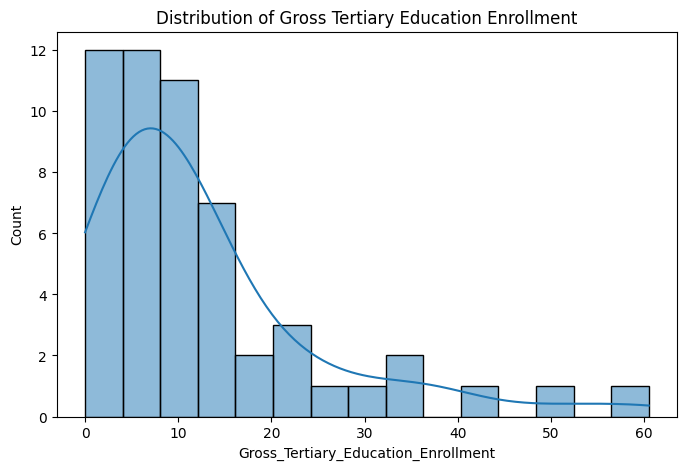

In [139]:
plt.figure(figsize=(8,5))
sns.histplot(df[target], bins=15, kde=True)
plt.title("Distribution of Gross Tertiary Education Enrollment")
plt.show()

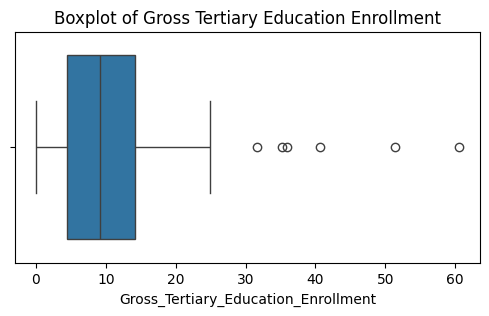

In [140]:
plt.figure(figsize=(6,3))
sns.boxplot(x=df[target])
plt.title("Boxplot of Gross Tertiary Education Enrollment")
plt.show()

In [141]:
X = df.drop(columns=[target])
y = df["Gross_Tertiary_Education_Enrollment"]

In [142]:
import json

feature_order = {
    "features": list(X.columns),
    "target": "Gross_Tertiary_Education_Enrollment"
}

with open("feature_order.json", "w") as f:
    json.dump(feature_order, f, indent=4)

print("feature_order.json saved successfully!")

feature_order.json saved successfully!


In [143]:
df_africa.to_csv("model_ready.csv", index=False)

In [144]:
print(X.shape)
print(y.shape)

(54, 25)
(54,)


In [145]:
corr_matrix = X.select_dtypes(include=np.number).corr().abs()

In [146]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [147]:
# Find columns with correlation greater than 0.90
to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print(to_drop)

['OOSR_Pre0Primary_Age_Female', 'OOSR_Primary_Age_Female', 'OOSR_Lower_Secondary_Age_Female', 'OOSR_Upper_Secondary_Age_Female', 'Completion_Rate_Primary_Female', 'Completion_Rate_Lower_Secondary_Male', 'Completion_Rate_Lower_Secondary_Female', 'Completion_Rate_Upper_Secondary_Male', 'Completion_Rate_Upper_Secondary_Female', 'Youth_15_24_Literacy_Rate_Female']


In [148]:
print(X.columns)

Index(['OOSR_Pre0Primary_Age_Male', 'OOSR_Pre0Primary_Age_Female',
       'OOSR_Primary_Age_Male', 'OOSR_Primary_Age_Female',
       'OOSR_Lower_Secondary_Age_Male', 'OOSR_Lower_Secondary_Age_Female',
       'OOSR_Upper_Secondary_Age_Male', 'OOSR_Upper_Secondary_Age_Female',
       'Completion_Rate_Primary_Male', 'Completion_Rate_Primary_Female',
       'Completion_Rate_Lower_Secondary_Male',
       'Completion_Rate_Lower_Secondary_Female',
       'Completion_Rate_Upper_Secondary_Male',
       'Completion_Rate_Upper_Secondary_Female',
       'Grade_2_3_Proficiency_Reading', 'Grade_2_3_Proficiency_Math',
       'Primary_End_Proficiency_Reading', 'Primary_End_Proficiency_Math',
       'Lower_Secondary_End_Proficiency_Reading',
       'Lower_Secondary_End_Proficiency_Math',
       'Youth_15_24_Literacy_Rate_Male', 'Youth_15_24_Literacy_Rate_Female',
       'Birth_Rate', 'Gross_Primary_Education_Enrollment',
       'Unemployment_Rate'],
      dtype='object')


In [149]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [150]:
print(X_train.shape)
print(X_test.shape)

(43, 25)
(11, 25)


In [151]:
# standardise the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [152]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [153]:
print(X.columns)

Index(['OOSR_Pre0Primary_Age_Male', 'OOSR_Pre0Primary_Age_Female',
       'OOSR_Primary_Age_Male', 'OOSR_Primary_Age_Female',
       'OOSR_Lower_Secondary_Age_Male', 'OOSR_Lower_Secondary_Age_Female',
       'OOSR_Upper_Secondary_Age_Male', 'OOSR_Upper_Secondary_Age_Female',
       'Completion_Rate_Primary_Male', 'Completion_Rate_Primary_Female',
       'Completion_Rate_Lower_Secondary_Male',
       'Completion_Rate_Lower_Secondary_Female',
       'Completion_Rate_Upper_Secondary_Male',
       'Completion_Rate_Upper_Secondary_Female',
       'Grade_2_3_Proficiency_Reading', 'Grade_2_3_Proficiency_Math',
       'Primary_End_Proficiency_Reading', 'Primary_End_Proficiency_Math',
       'Lower_Secondary_End_Proficiency_Reading',
       'Lower_Secondary_End_Proficiency_Math',
       'Youth_15_24_Literacy_Rate_Male', 'Youth_15_24_Literacy_Rate_Female',
       'Birth_Rate', 'Gross_Primary_Education_Enrollment',
       'Unemployment_Rate'],
      dtype='object')


In [154]:
# Model training
# Model1: Linear regression
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_predictions = linear_model.predict(X_test_scaled)

In [155]:
# Model2: SGD Regressor
sgd_model = SGDRegressor(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(X_train_scaled, y_train)

sgd_predictions = sgd_model.predict(X_test_scaled)

In [156]:
# Model3: Decision Tree
tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

In [157]:
# Model4: Random Forest
rf_model = RandomForestRegressor(
    random_state=42,
    n_estimators=1000
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [158]:
learning_rate = 0.01
n_epochs = 100

train_losses = []
test_losses = []

theta = np.random.rand(X_train_scaled.shape[1])

for epoch in range(n_epochs):
    # Training predictions and loss
    train_predictions = X_train_scaled @ theta
    train_loss = mean_squared_error(y_train, train_predictions)
    train_losses.append(train_loss)

    # Testing predictions and loss
    test_predictions = X_test_scaled @ theta
    test_loss = mean_squared_error(y_test, test_predictions)
    test_losses.append(test_loss)

    # Gradient calculation and parameter update
    gradient = (2/len(X_train_scaled)) * X_train_scaled.T @ (train_predictions - y_train)
    theta = theta - learning_rate * gradient

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

print("\nGradient Descent Training Complete.")

Epoch 10/100, Train Loss: 279.4109, Test Loss: 133.4393
Epoch 20/100, Train Loss: 251.9528, Test Loss: 147.1409
Epoch 30/100, Train Loss: 241.7651, Test Loss: 154.7993
Epoch 40/100, Train Loss: 236.5200, Test Loss: 158.6671
Epoch 50/100, Train Loss: 233.4003, Test Loss: 160.9772
Epoch 60/100, Train Loss: 231.3900, Test Loss: 162.6002
Epoch 70/100, Train Loss: 230.0076, Test Loss: 163.8371
Epoch 80/100, Train Loss: 228.9974, Test Loss: 164.8083
Epoch 90/100, Train Loss: 228.2174, Test Loss: 165.5821
Epoch 100/100, Train Loss: 227.5864, Test Loss: 166.2096

Gradient Descent Training Complete.


In [159]:
results = pd.DataFrame(columns=['Model', 'MAE', 'RMSE', 'R2'])

In [160]:
# Manual Gradient Descent Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

theta = np.random.rand(X_train.shape[1])

manual_predictions = X_test_scaled @ theta

manual_mae = mean_absolute_error(y_test, manual_predictions)
manual_rmse = np.sqrt(mean_squared_error(y_test, manual_predictions))
manual_r2 = r2_score(y_test, manual_predictions)

print("Manual Gradient Descent")
print("------------------------------")
print(f"MAE : {manual_mae:.3f}")
print(f"RMSE: {manual_rmse:.3f}")
print(f"R²  : {manual_r2:.3f}")

# Add Manual Gradient Descent results
results.loc["Manual Gradient Descent"] = {
    "Model": "Manual Gradient Descent",
    "MAE": manual_mae,
    "RMSE": manual_rmse,
    "R2": manual_r2
}


# Compare All Models
comparison = pd.DataFrame(results).sort_values("RMSE")

print("\nModel Comparison")
print(comparison)


Manual Gradient Descent
------------------------------
MAE : 9.998
RMSE: 12.104
R²  : -0.790

Model Comparison
                                           Model      MAE       RMSE        R2
Manual Gradient Descent  Manual Gradient Descent  9.99772  12.103556 -0.790218


In [161]:
train_losses
test_losses

[143.07736981986602,
 136.99875984106788,
 133.11603726545448,
 130.86175177202668,
 129.80488892662922,
 129.61828166502866,
 130.05393880819645,
 130.92432267644747,
 132.08810726587683,
 133.43931912453738,
 134.89903854365411,
 136.40904370045678,
 137.9269332170883,
 139.42237672347702,
 140.87422839981147,
 142.26830249875334,
 143.5956579656,
 144.85127552906488,
 146.03303802472388,
 147.1409454642629,
 148.17651213251347,
 149.14230501446715,
 150.0415920465766,
 150.8780757390322,
 151.65569314421379,
 152.37846733868835,
 153.05039883387806,
 153.67538785435673,
 154.25718038973696,
 154.7993324632914,
 155.30518826469049,
 155.777868739697,
 156.22026797329696,
 156.63505528851263,
 157.02468144502197,
 157.39138768612528,
 157.7372166701428,
 158.06402454910815,
 158.37349363629428,
 158.66714524463103,
 158.94635238831134,
 159.21235212607448,
 159.46625739173848,
 159.709068209468,
 159.94168223114278,
 160.16490456353563,
 160.37945687581447,
 160.5859857947489,
 160.78

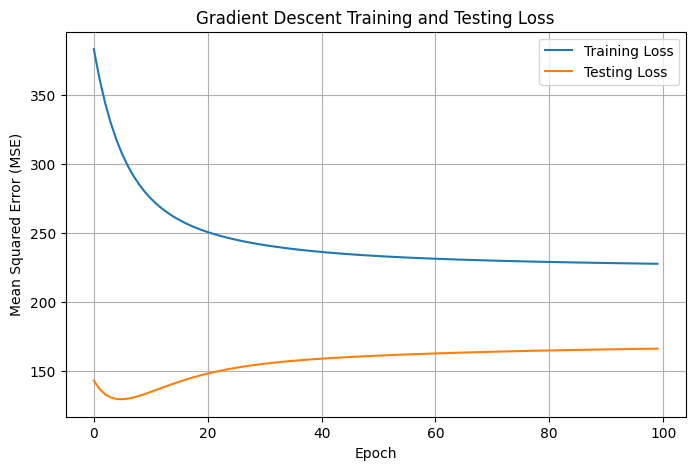

In [162]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Testing Loss")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Gradient Descent Training and Testing Loss")
plt.legend()
plt.grid(True)

plt.savefig("loss_curve_gradient_descent.png")
plt.show()

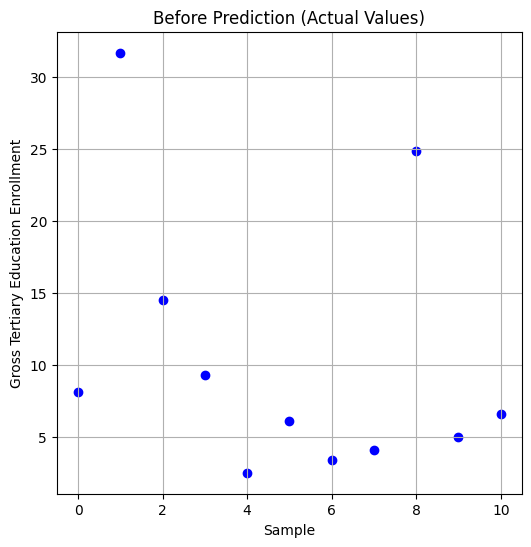

In [163]:
plt.figure(figsize=(6,6))

plt.scatter(range(len(y_test)), y_test, color="blue")

plt.title("Before Prediction (Actual Values)")
plt.xlabel("Sample")
plt.ylabel("Gross Tertiary Education Enrollment")

plt.grid(True)
plt.show()

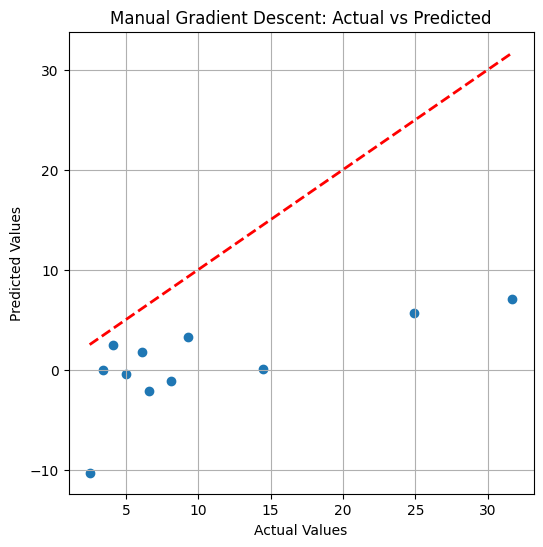

In [164]:
manual_predictions = X_test_scaled @ theta

plt.figure(figsize=(6,6))

plt.scatter(y_test, manual_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Manual Gradient Descent: Actual vs Predicted")

plt.grid(True)
plt.show()

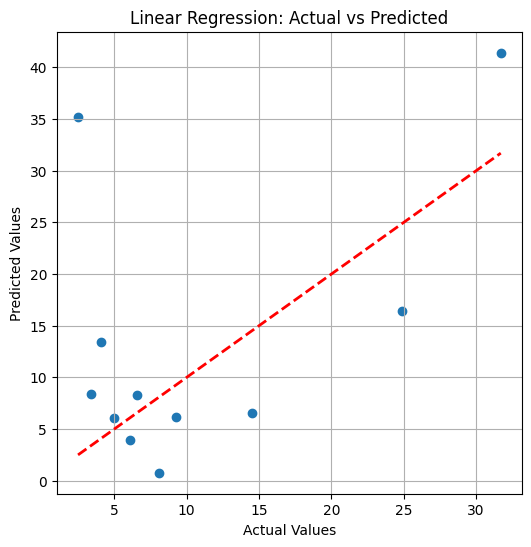

In [165]:
linear_predictions = linear_model.predict(X_test_scaled)

plt.figure(figsize=(6,6))

plt.scatter(y_test, linear_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")

plt.grid(True)
plt.show()

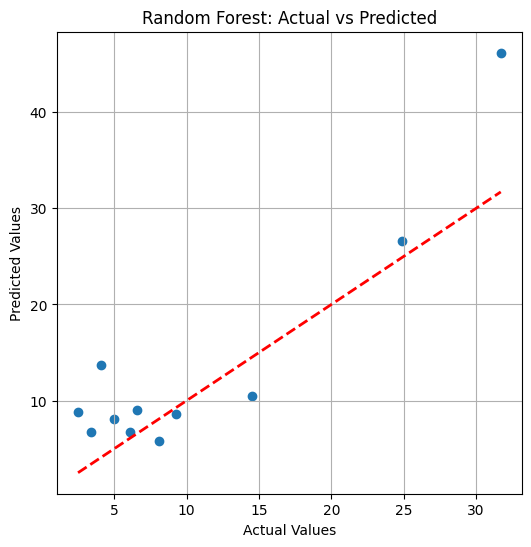

In [166]:
rf_predictions = rf_model.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")

plt.grid(True)
plt.show()

In [167]:
# comparison table of models
results.to_csv("model_comparison.csv", index=False)

In [168]:
# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, y_true, predictions):

    mae = mean_absolute_error(y_true, predictions)
    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, predictions)

    print(f"\n{name}")
    print("-" * 30)
    print(f"MAE : {mae:.3f}")
    print(f"MSE : {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²  : {r2:.3f}")

In [169]:
evaluate_model("Linear Regression", y_test, linear_predictions)

evaluate_model("SGD Regressor", y_test, sgd_predictions)

evaluate_model("Decision Tree", y_test, tree_predictions)

evaluate_model("Random Forest", y_test, rf_predictions)


Linear Regression
------------------------------
MAE : 8.050
MSE : 134.912
RMSE: 11.615
R²  : -0.649

SGD Regressor
------------------------------
MAE : 7.321
MSE : 95.262
RMSE: 9.760
R²  : -0.164

Decision Tree
------------------------------
MAE : 8.700
MSE : 140.965
RMSE: 11.873
R²  : -0.723

Random Forest
------------------------------
MAE : 4.425
MSE : 35.882
RMSE: 5.990
R²  : 0.562


In [170]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best R² score:", grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
best_rf_predictions = best_rf_model.predict(X_test)

evaluate_model("Tuned Random Forest", y_test, best_rf_predictions)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best R² score: -0.5272160441456533

Tuned Random Forest
------------------------------
MAE : 4.420
MSE : 40.428
RMSE: 6.358
R²  : 0.506


In [171]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "SGD Regressor",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, sgd_predictions),
        mean_absolute_error(y_test, tree_predictions),
        mean_absolute_error(y_test, rf_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, sgd_predictions)),
        np.sqrt(mean_squared_error(y_test, tree_predictions)),
        np.sqrt(mean_squared_error(y_test, rf_predictions))
    ],
    "R2": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, sgd_predictions),
        r2_score(y_test, tree_predictions),
        r2_score(y_test, rf_predictions)
    ]
})

results.sort_values(by="R2", ascending=False)

,Model,MAE,RMSE,R2
3,Random Forest,4.424764,5.990176,0.561510
1,SGD Regressor,7.321396,9.760249,-0.164131
0,Linear Regression,8.049770,11.615153,-0.648655
2,Decision Tree,8.700000,11.872849,-0.722622


In [172]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [173]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [174]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                                    Feature  Importance
22                               Birth_Rate    0.338018
19     Lower_Secondary_End_Proficiency_Math    0.146229
24                        Unemployment_Rate    0.092015
23       Gross_Primary_Education_Enrollment    0.069911
20           Youth_15_24_Literacy_Rate_Male    0.038640
10     Completion_Rate_Lower_Secondary_Male    0.027285
1               OOSR_Pre0Primary_Age_Female    0.025778
8              Completion_Rate_Primary_Male    0.024718
0                 OOSR_Pre0Primary_Age_Male    0.019933
6             OOSR_Upper_Secondary_Age_Male    0.019881
11   Completion_Rate_Lower_Secondary_Female    0.019871
16          Primary_End_Proficiency_Reading    0.019812
3                   OOSR_Primary_Age_Female    0.019054
2                     OOSR_Primary_Age_Male    0.018745
5           OOSR_Lower_Secondary_Age_Female    0.018608
17             Primary_End_Proficiency_Math    0.017649
21         Youth_15_24_Literacy_Rate_Female    0

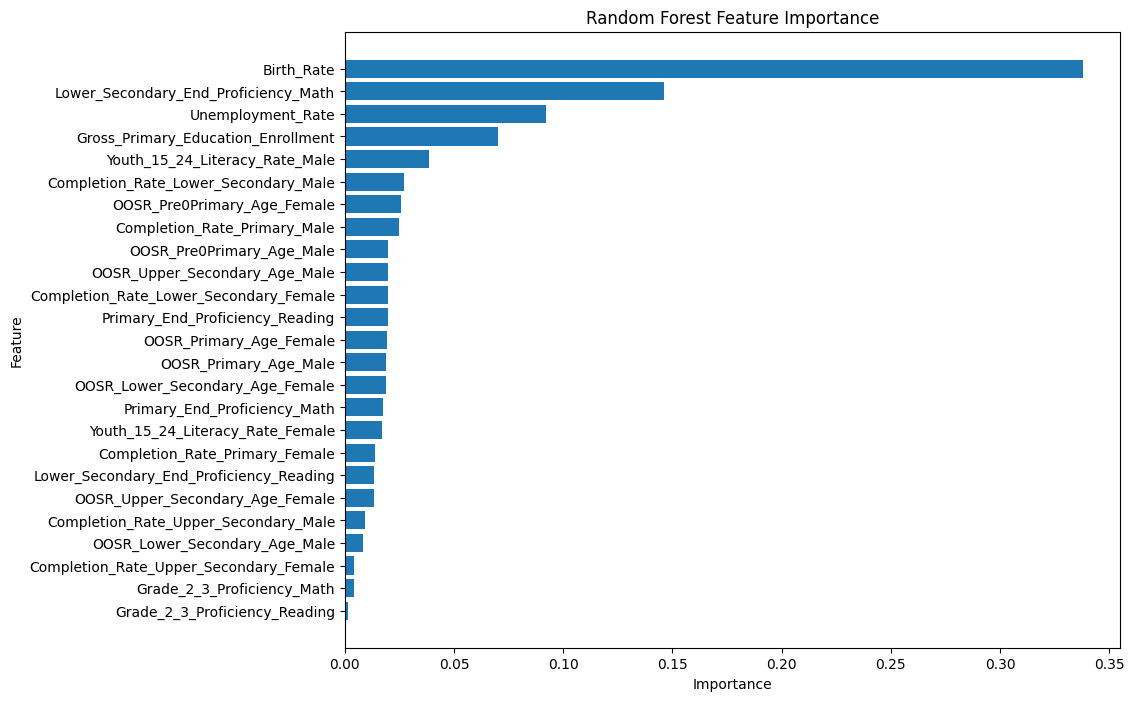

In [175]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.show()

In [176]:
corr = df.corr(numeric_only=True)[target]

print(
    corr.sort_values(ascending=False)
)

Gross_Tertiary_Education_Enrollment        1.000000
Lower_Secondary_End_Proficiency_Math       0.550726
Lower_Secondary_End_Proficiency_Reading    0.479845
Unemployment_Rate                          0.433341
Primary_End_Proficiency_Reading            0.260049
Primary_End_Proficiency_Math               0.245233
Gross_Primary_Education_Enrollment         0.233287
Completion_Rate_Upper_Secondary_Female     0.200902
Completion_Rate_Lower_Secondary_Female     0.198416
Completion_Rate_Lower_Secondary_Male       0.094573
Youth_15_24_Literacy_Rate_Female           0.093832
Youth_15_24_Literacy_Rate_Male             0.072215
Completion_Rate_Primary_Female             0.045001
Grade_2_3_Proficiency_Reading              0.032604
Completion_Rate_Primary_Male               0.028851
Completion_Rate_Upper_Secondary_Male       0.026208
Grade_2_3_Proficiency_Math                -0.097236
OOSR_Pre0Primary_Age_Female               -0.194791
OOSR_Pre0Primary_Age_Male                 -0.201239
OOSR_Lower_S

In [177]:
print(df[target].describe())

count    54.000000
mean     12.585185
std      12.702717
min       0.000000
25%       4.425000
50%       9.150000
75%      14.225000
max      60.500000
Name: Gross_Tertiary_Education_Enrollment, dtype: float64


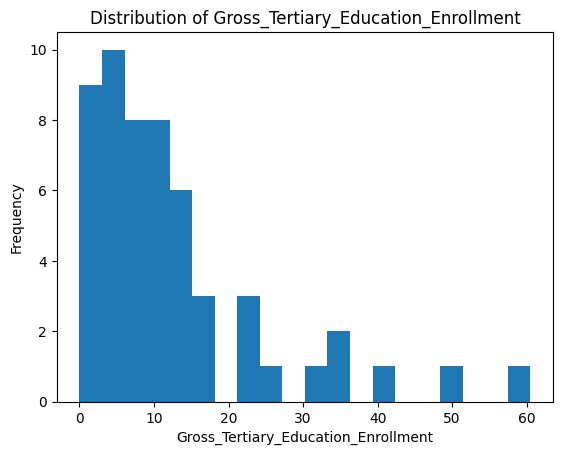

In [178]:
import matplotlib.pyplot as plt

plt.hist(
    df[target],
    bins=20
)

plt.xlabel(target)
plt.ylabel("Frequency")
plt.title("Distribution of " + target)

plt.show()

In [179]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score

dummy = DummyRegressor(strategy="mean")

dummy.fit(X_train, y_train)

prediction = dummy.predict(X_test)

print(
    "Baseline R²:",
    r2_score(y_test, prediction)
)

Baseline R²: -0.07875879618124881


In [180]:
df[target].describe()

,Gross_Tertiary_Education_Enrollment
count,54.000000
mean,12.585185
std,12.702717
min,0.000000
25%,4.425000
50%,9.150000
75%,14.225000
max,60.500000


In [181]:
print(df.corr(numeric_only=True)[target].sort_values())

Birth_Rate                                -0.546663
OOSR_Primary_Age_Female                   -0.346450
OOSR_Upper_Secondary_Age_Female           -0.345767
OOSR_Primary_Age_Male                     -0.343444
OOSR_Upper_Secondary_Age_Male             -0.329096
OOSR_Lower_Secondary_Age_Male             -0.326348
OOSR_Lower_Secondary_Age_Female           -0.312431
OOSR_Pre0Primary_Age_Male                 -0.201239
OOSR_Pre0Primary_Age_Female               -0.194791
Grade_2_3_Proficiency_Math                -0.097236
Completion_Rate_Upper_Secondary_Male       0.026208
Completion_Rate_Primary_Male               0.028851
Grade_2_3_Proficiency_Reading              0.032604
Completion_Rate_Primary_Female             0.045001
Youth_15_24_Literacy_Rate_Male             0.072215
Youth_15_24_Literacy_Rate_Female           0.093832
Completion_Rate_Lower_Secondary_Male       0.094573
Completion_Rate_Lower_Secondary_Female     0.198416
Completion_Rate_Upper_Secondary_Female     0.200902
Gross_Primar

In [182]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Average R²:", scores.mean())

[ 0.68147659 -1.1691038   0.32782767  0.7348706   0.24613961]
Average R²: 0.1642421354503706


In [183]:
df = df_africa.copy()
print(df.shape)

(54, 29)


In [184]:
import joblib

In [185]:
# saved best model
joblib.dump(rf_model, "best_model.pkl")

['best_model.pkl']

In [186]:
loaded_model = joblib.load("best_model.pkl")

In [187]:
prediction = loaded_model.predict(X_test)

print(prediction[:5])

[ 5.461 47.493 10.16   8.571  8.728]
